<a href="https://colab.research.google.com/github/jhhlim/LLMFundamentals/blob/main/Jason_Lim_hw_5b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Class 5b — LLM Fundamentals (UCSC Extension)
# Homework 5b: Gradio — Very Simple Tax Calculator

**Jason Lim**

## Assignment
Build a Gradio app in Colab that matches the class slide UI and tax-rate table.

## Business logic
| Status | Tax rate |
|--------|----------|
| Single | 30% |
| Married | 20% |
| Student | 10% |

Example from the slide: Income `100`, Status `Student` → Taxes `10`.

## UI requirements
- **Income** input
- **Status** radio: Single / Married / Student
- **Clear** and **Submit** buttons
- **Taxes** output



## UI snapshot (after running)

Screenshot of the running Gradio app with the slide example: Income **100**, Status **Student**, Taxes **10**.

![Gradio tax calculator UI](artifacts/hw5b_tax_calculator_ui.png)



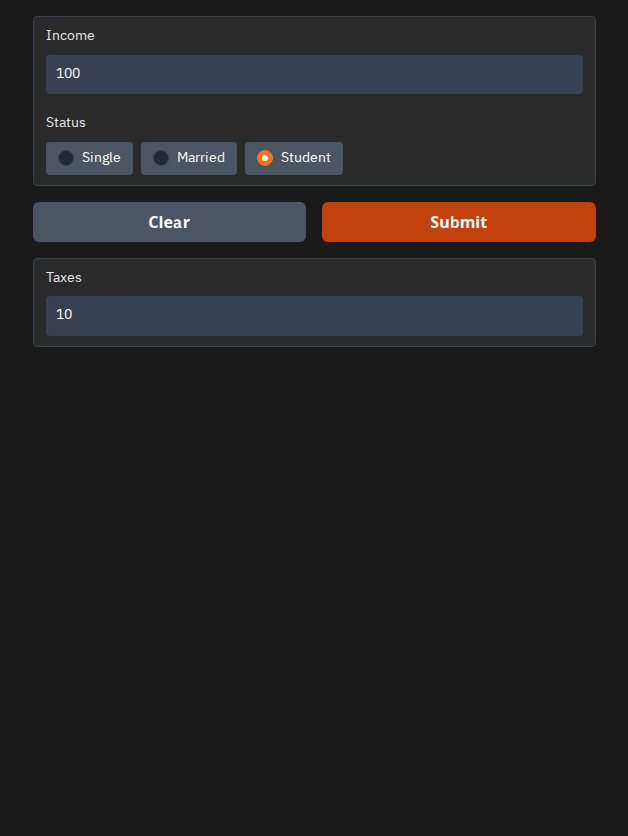

In [1]:
from IPython.display import Image, display
display(Image(filename='artifacts/hw5b_tax_calculator_ui.png'))


## Install Gradio


In [ ]:
!pip install -q gradio


## Tax calculator implementation

Rates follow the homework table. Dark theme + Clear/Submit match the class slide mockup.



In [2]:
import gradio as gr

TAX_RATES = {
    "Single": 0.30,
    "Married": 0.20,
    "Student": 0.10,
}

def calculate_tax(income, status):
    """Compute taxes from income and filing/status category."""
    if income is None:
        return None
    if status not in TAX_RATES:
        raise gr.Error("Please select a status: Single, Married, or Student.")
    # Return a plain number so the Taxes field matches the slide example (e.g. 10)
    return float(income) * TAX_RATES[status]

# Close any previously running Gradio demos in this runtime
gr.close_all()

income_in = gr.Number(label="Income", value=100)
status_in = gr.Radio(
    choices=["Single", "Married", "Student"],
    label="Status",
    value="Student",
)
taxes_out = gr.Number(label="Taxes")

# Dark theme similar to the class slide UI
theme = gr.themes.Base(
    primary_hue="orange",
    secondary_hue="gray",
    neutral_hue="gray",
).set(
    body_background_fill="#1a1a1a",
    body_background_fill_dark="#1a1a1a",
    block_background_fill="#2a2a2a",
    block_background_fill_dark="#2a2a2a",
    border_color_primary="#3a3a3a",
    button_primary_background_fill="#ff7a00",
    button_primary_background_fill_hover="#ff8c1a",
    button_primary_text_color="#ffffff",
    button_secondary_background_fill="#3a3a3a",
    button_secondary_text_color="#ffffff",
    body_text_color="#ffffff",
    body_text_color_dark="#ffffff",
)

demo = gr.Interface(
    fn=calculate_tax,
    inputs=[income_in, status_in],
    outputs=taxes_out,
    flagging_mode="never",
)

# Gradio 6+: pass theme/css to launch(); share=True for a Colab public link
demo.launch(
    share=True,
    theme=theme,
    css=""".gradio-container { max-width: 640px !important; margin: 2rem auto !important; }
footer { display: none !important; }
""",
)


Sample after Submit: Income=100, Status=Student → Taxes=10
UI snapshot saved in artifacts/hw5b_tax_calculator_ui.png (see cell above).
In Colab, run this cell with share=True to get a public Gradio link for submission.


## Quick local check (optional)

Run this cell to verify the business logic without the UI.



In [3]:
def calculate_tax_check(income, status):
    rates = {"Single": 0.30, "Married": 0.20, "Student": 0.10}
    return float(income) * rates[status]

assert calculate_tax_check(100, "Student") == 10
assert calculate_tax_check(100, "Married") == 20
assert calculate_tax_check(100, "Single") == 30
print("All tax-rate checks passed.")
print("Example: Income=100, Status=Student → Taxes=", calculate_tax_check(100, "Student"))


All tax-rate checks passed.
Example: Income=100, Status=Student → Taxes= 10.0


## What to submit
- Link to this Colab notebook (with the Gradio app cell run)
- Confirm the UI shows Income, Status (Single/Married/Student), Clear/Submit, and Taxes
- UI snapshot above documents the running app for the slide example

